In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import random
import math
from scipy.stats import pearsonr
sns.set()

In [ ]:
data_2015 = pd.read_csv("/content/2015.csv", sep = ",")
data_2016 = pd.read_csv("/content/2016.csv", sep = ",")
data_2017 = pd.read_csv("/content/2017.csv", sep = ",")
data_2018 = pd.read_csv("/content/2018 (1).csv", sep = ",")
data_2019 = pd.read_csv("/content/2019.csv", sep = ",")
data_2020 = pd.read_csv("/content/2020.csv", sep = ",")
data_2021 = pd.read_csv("/content/2021.csv", sep = ",")
data_2022 = pd.read_csv("/content/2022.csv", sep = ",")
ladder = pd.read_csv("/content/happiness-cantril-ladder.csv", sep = ",")

In [ ]:
data_2021 = pd.read_csv("/content/2021.csv", sep = ",")

In [ ]:
ladder = pd.read_csv("/content/happiness-cantril-ladder.csv", sep = ",")

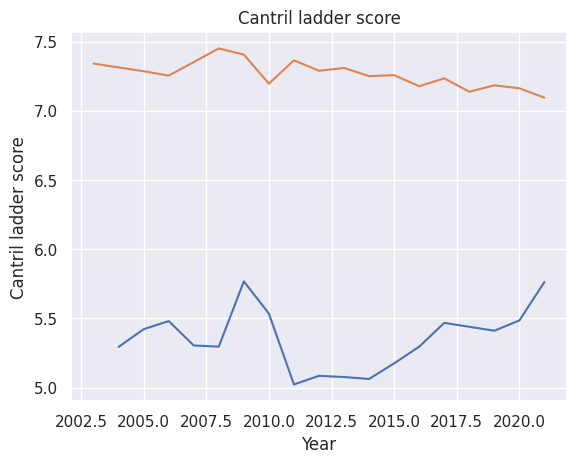

In [ ]:
plt.plot(ladder[ladder.Entity=="Vietnam"]["Year"],ladder[ladder.Entity=="Vietnam"]["Cantril ladder score"], label="Vietnam")
plt.plot(ladder[ladder.Entity=="Australia"]["Year"],ladder[ladder.Entity=="Australia"]["Cantril ladder score"],label="Australia")
plt.xlabel('Year')
plt.ylabel('Cantril ladder score')
plt.title('Cantril ladder score')
plt.show()

In [ ]:
Europe_ladder= data_2021[data_2021["Regional indicator"]=="Western Europe"]["Ladder score"]
Europe_ladder.describe()

count    21.000000
mean      6.914905
std       0.656519
min       5.536000
25%       6.491000
50%       7.085000
75%       7.392000
max       7.842000
Name: Ladder score, dtype: float64

In [ ]:
data_2021=data_2021[["Country name","Regional indicator", "Ladder score", "Logged GDP per capita", "Social support", "Healthy life expectancy", "Freedom to make life choices" ]].copy()
data_2021

,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
0,Finland,Western Europe,7.842,10.775,0.954,72.000,0.949
1,Denmark,Western Europe,7.620,10.933,0.954,72.700,0.946
2,Switzerland,Western Europe,7.571,11.117,0.942,74.400,0.919
3,Iceland,Western Europe,7.554,10.878,0.983,73.000,0.955
4,Netherlands,Western Europe,7.464,10.932,0.942,72.400,0.913
...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,7.926,0.787,48.700,0.715
145,Botswana,Sub-Saharan Africa,3.467,9.782,0.784,59.269,0.824
146,Rwanda,Sub-Saharan Africa,3.415,7.676,0.552,61.400,0.897
147,Zimbabwe,Sub-Saharan Africa,3.145,7.943,0.750,56.201,0.677


In [ ]:
Europe=pd.concat([data_2021[data_2021["Regional indicator"]=="Central and Eastern Europe"], data_2021[data_2021["Regional indicator"]=="Western Europe"]])
Europe_ladder=Europe["Ladder score"]
Asia=pd.concat([data_2021[data_2021["Regional indicator"]=="East Asia"], data_2021[data_2021["Regional indicator"]=="South Asia"],data_2021[data_2021["Regional indicator"]=="Southeast Asia"]])
Asia_ladder= Asia["Ladder score"]
America=pd.concat([data_2021[data_2021["Regional indicator"]=="Latin America and Caribbean"], data_2021[data_2021["Regional indicator"]=="North America and ANZ"]])
America_ladder= America["Ladder score"]
Africa= pd.concat([data_2021[data_2021["Regional indicator"]=="Middle East and North Africa"], data_2021[data_2021["Regional indicator"]=="Sub-Saharan Africa"]])
Africa_ladder= Africa["Ladder score"]

In [ ]:
Africa_ladder= data_2021[data_2021["Regional indicator"]=="Sub-Saharan Africa"]["Ladder score"]
Africa_ladder.describe()

count    36.000000
mean      4.494472
std       0.654892
min       3.145000
25%       4.098500
50%       4.616000
75%       4.999250
max       6.049000
Name: Ladder score, dtype: float64

In [ ]:
America_ladder.describe()

count    24.000000
mean      6.111458
std       0.784613
min       3.615000
25%       5.821000
50%       6.116500
75%       6.432000
max       7.277000
Name: Ladder score, dtype: float64

In [ ]:
data_2021.columns
data_2021.dtypes

Country name                     object
Regional indicator               object
Ladder score                    float64
Logged GDP per capita           float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
dtype: object

In [ ]:
# Checking for nan values
data_2021.isna().sum()

Country name                    0
Regional indicator              0
Ladder score                    0
Logged GDP per capita           0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
dtype: int64

In [ ]:
region_avg = data_2021.groupby(['Regional indicator']).mean(numeric_only=True)
region_avg.head()

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Regional indicator,,,,,
Central and Eastern Europe,5.984765,10.109059,0.887412,68.338412,0.797059
Commonwealth of Independent States,5.467000,9.401833,0.872500,65.009500,0.816917
East Asia,5.810333,10.367667,0.860500,71.252167,0.763500
Latin America and Caribbean,5.908050,9.370000,0.839500,67.076050,0.831750
Middle East and North Africa,5.219765,9.666118,0.797647,65.609118,0.716471


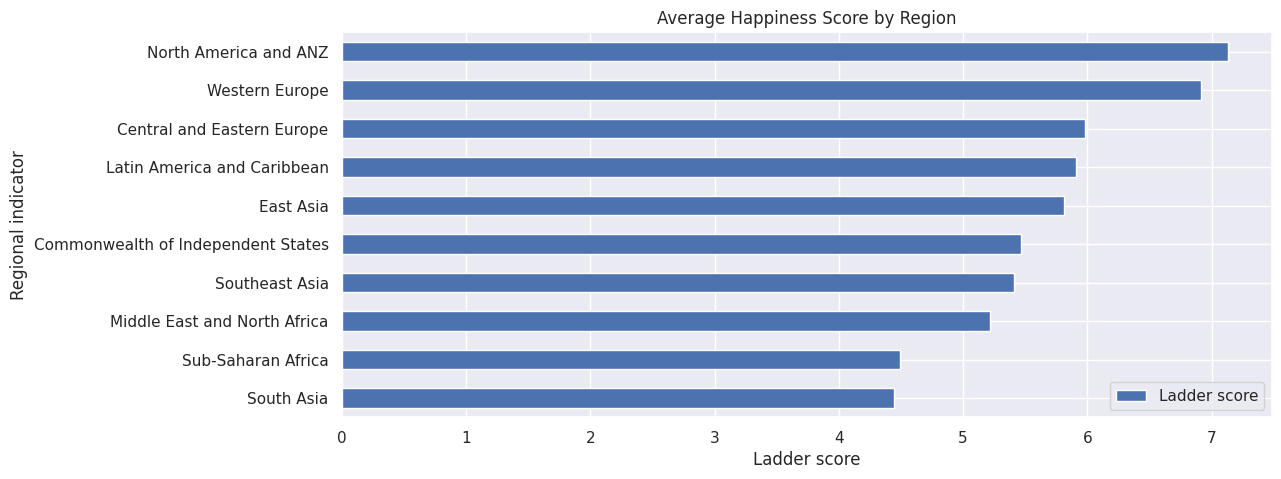

In [ ]:
ax= data_2021.groupby('Regional indicator')[['Ladder score']].mean().sort_values('Ladder score').plot(kind='barh', figsize=(12, 5), title='Average Happiness Score by Region')
ax.set_xlabel('Ladder score')
plt.show()

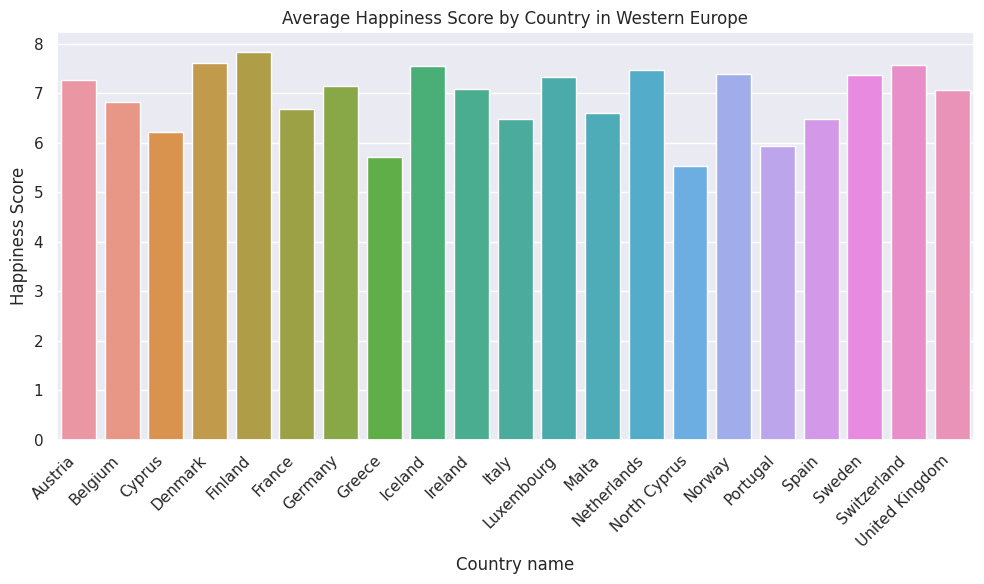

In [ ]:
europe = data_2021[data_2021["Regional indicator"] == "Western Europe"]
by_country = europe.groupby("Country name", as_index=False)
happiness_by_country = by_country["Ladder score"].mean()
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="Country name", y="Ladder score", data=happiness_by_country)
barplot.set_xlabel("Country name")
barplot.set_ylabel("Happiness Score")
barplot.set_title("Average Happiness Score by Country in Western Europe")
barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

**This visualization shows the happiness score for each countery in western europe and shows that Finland, Denmark and Iceland have the highest happiness score**

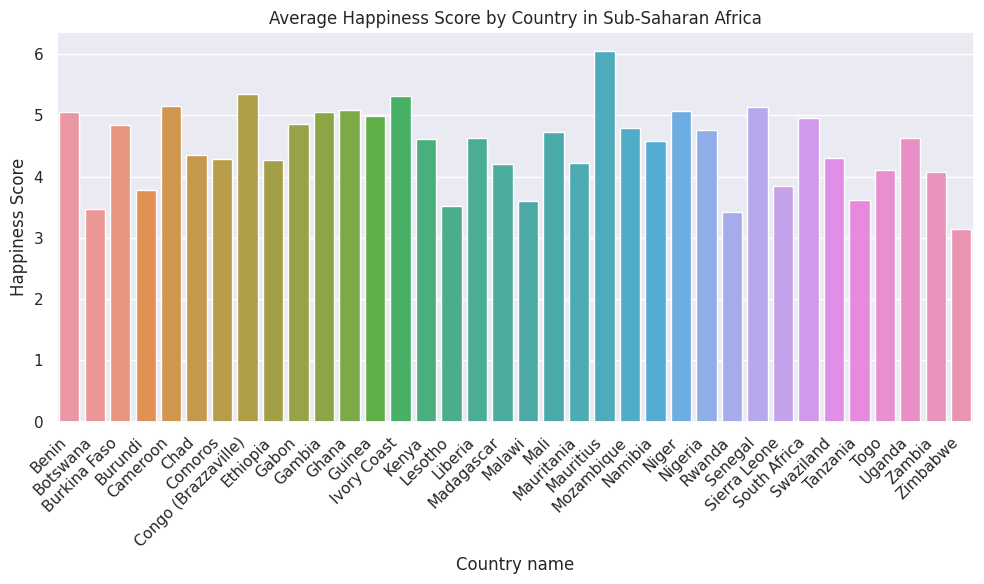

In [ ]:
africa = data_2021[data_2021["Regional indicator"] == "Sub-Saharan Africa"]
by_country = africa.groupby("Country name", as_index=False)
happiness_by_country = by_country["Ladder score"].mean()
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="Country name", y="Ladder score", data=happiness_by_country)
barplot.set_xlabel("Country name")
barplot.set_ylabel("Happiness Score")
barplot.set_title("Average Happiness Score by Country in Sub-Saharan Africa")
barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

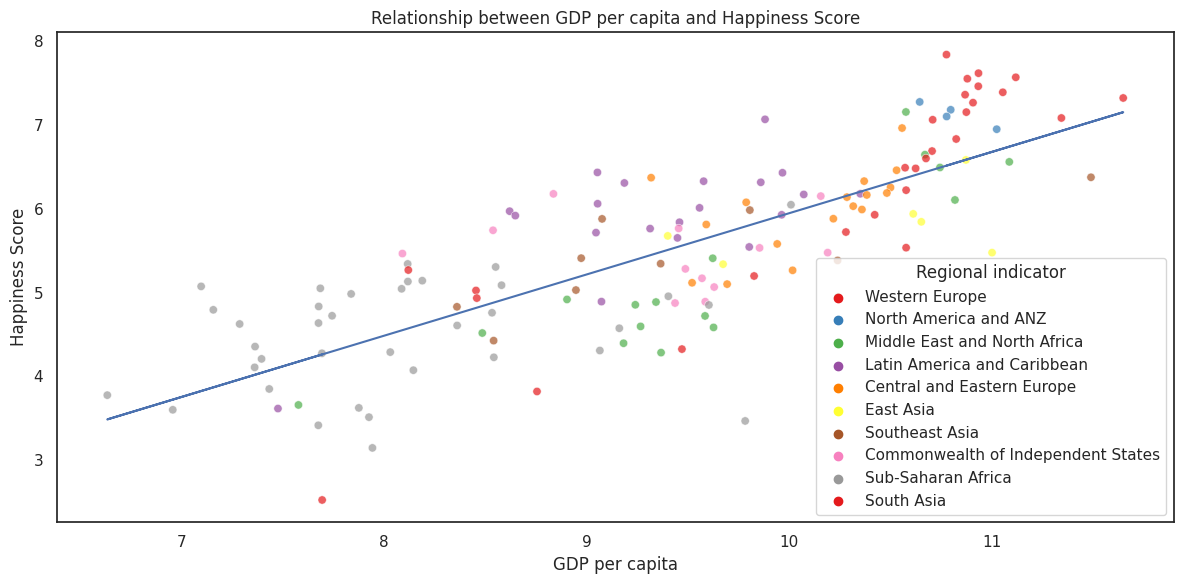

In [ ]:
x= data_2021["Logged GDP per capita"]
y= data_2021["Ladder score"]
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))
scatterplot = sns.scatterplot(x ="Logged GDP per capita", y="Ladder score", sizes=(20, 200), hue="Regional indicator", alpha=0.7, palette="Set1", data=data_2021)
scatterplot.set_xlabel("GDP per capita")
scatterplot.set_ylabel("Happiness Score")
scatterplot.set_title("Relationship between GDP per capita and Happiness Score")
plt.legend(title="Regional indicator")
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x+b)
plt.tight_layout()
plt.show()

**This visualization shows a relation between the happiness score and Economy which shows that when the Economy is better the level of happiness rises**

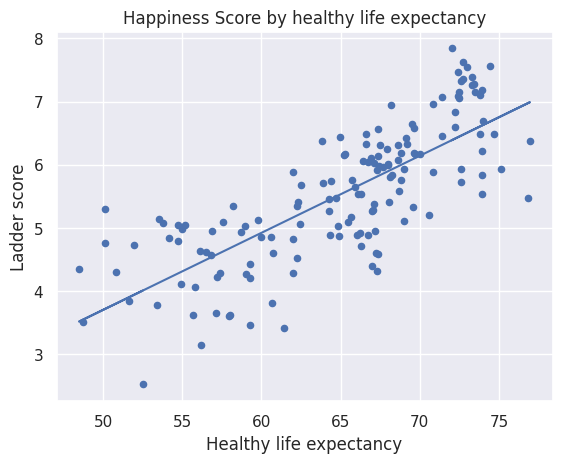

In [ ]:
#ploting Healthy life expectancy and happiness score to find for a correlation
data_2021.plot(kind='scatter', x='Healthy life expectancy', y='Ladder score', title='Happiness Score by healthy life expectancy')
z = data_2021['Healthy life expectancy']
t = data_2021['Ladder score']
m, b = np.polyfit(z, t, 1)
plt.plot(z, m*z+b)
plt.show()

In [ ]:
corr_coef, p_value = pearsonr(x, y)

# **Hypothesis Testing**:
1. Two samples: there is no difference in happiness scores between Western Europe and Sub-Saharans Africa
+ t= 13.44
+ The p-value is < .00001.

In [ ]:
(Europe_ladder.mean()- Asia_ladder.mean())-0.5854358007

0.7032173093478473

In [ ]:
data_2021.describe()

,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.00,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.532839,0.058752,5.648007,5.417631,9.432208,0.814745,64.992799,0.791597,-0.015134,0.727450,2.43,0.977161,0.793315,0.520161,0.498711,0.178047,0.135141,2.430329
std,1.073924,0.022001,1.054330,1.094879,1.158601,0.114889,6.762043,0.113332,0.150657,0.179226,0.00,0.404740,0.258871,0.213019,0.137888,0.098270,0.114361,0.537645
min,2.523000,0.026000,2.596000,2.449000,6.635000,0.463000,48.478000,0.382000,-0.288000,0.082000,2.43,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.648000
25%,4.852000,0.043000,4.991000,4.706000,8.541000,0.750000,59.802000,0.718000,-0.126000,0.667000,2.43,0.666000,0.647000,0.357000,0.409000,0.105000,0.060000,2.138000
50%,5.534000,0.054000,5.625000,5.413000,9.569000,0.832000,66.603000,0.804000,-0.036000,0.781000,2.43,1.025000,0.832000,0.571000,0.514000,0.164000,0.101000,2.509000
75%,6.255000,0.070000,6.344000,6.128000,10.421000,0.905000,69.600000,0.877000,0.079000,0.845000,2.43,1.323000,0.996000,0.665000,0.603000,0.239000,0.174000,2.794000
max,7.842000,0.173000,7.904000,7.780000,11.647000,0.983000,76.953000,0.970000,0.542000,0.939000,2.43,1.751000,1.172000,0.897000,0.716000,0.541000,0.547000,3.482000


In [ ]:
Africa_ladder.describe()

count    53.000000
mean      4.727113
std       0.844229
min       3.145000
25%       4.275000
50%       4.721000
75%       5.051000
max       7.157000
Name: Ladder score, dtype: float64

In [ ]:
S= (((37*(0.746926)**2)+ 52*(0.844229**2)) /(38+53-2))
S

0.6483575063094831

In [ ]:
t= ((6.498789-4.727113)/np.sqrt(S*((1/38)+(1/53))))
t

10.351089587760518

In [ ]:
## The p-value is < 0.00001

# **Confidence interval**

In [ ]:
# Confidence interval for Europe
confidence_level = 0.95  # 95% confidence level
alpha = 1 - confidence_level
critical_value = st.t.ppf(1 - alpha / 2, df=len(Europe_ladder) - 1)
margin_of_error = critical_value * Europe_ladder.std()/ np.sqrt(len(Europe_ladder))
confidence_interval_E = (Europe_ladder.mean() - margin_of_error, Europe_ladder.mean() + margin_of_error)
confidence_interval_E

(6.253281079946865, 6.744297867421557)

In [ ]:
confidence_level = 0.95  # 95% confidence level
alpha = 1 - confidence_level
critical_value = st.t.ppf(1 - alpha / 2, df=len(Asia_ladder) - 1)
margin_of_error = critical_value * Asia_ladder.std()/ np.sqrt(len(Asia_ladder))
confidence_interval_As = (Asia_ladder.mean() - margin_of_error, Asia_ladder.mean() + margin_of_error)
confidence_interval_As

(4.817437334761464, 5.602835392511264)

In [ ]:
# Confidence interval for America
confidence_level = 0.95  # 95% confidence level
alpha = 1 - confidence_level
critical_value = st.t.ppf(1 - alpha / 2, df=len(America_ladder) - 1)
margin_of_error = critical_value * America_ladder.std()/ np.sqrt(len(America_ladder))
confidence_interval_Am = (America_ladder.mean() - margin_of_error, America_ladder.mean() + margin_of_error)
confidence_interval_Am


(5.780145319416856, 6.442771347249809)

In [ ]:
# Confidence interval for Africa
confidence_level = 0.95  # 95% confidence level
alpha = 1 - confidence_level
critical_value = st.t.ppf(1 - alpha / 2, df=len(Africa_ladder) - 1)
margin_of_error = critical_value * Africa_ladder.std()/ np.sqrt(len(Africa_ladder))
confidence_interval_A = (Africa_ladder.mean() - margin_of_error, Africa_ladder.mean() + margin_of_error)
confidence_interval_A

(4.4944147822725435, 4.959811632821796)

In [ ]:
Common= data_2021[data_2021["Regional indicator"]=="Commonwealth of Independent States"]
Common_ladder=Common["Ladder score"]

In [ ]:
# Confidence interval for Common
confidence_level = 0.95  # 95% confidence level
alpha = 1 - confidence_level
critical_value = st.t.ppf(1 - alpha / 2, df=len(Common_ladder) - 1)
margin_of_error = critical_value * Common_ladder.std()/ np.sqrt(len(Common_ladder))
confidence_interval_C = (Common_ladder.mean() - margin_of_error, Common_ladder.mean() + margin_of_error)
confidence_interval_C

(5.188634369057712, 5.745365630942287)

In [ ]:
meanAsia_ladder= 5.6901364

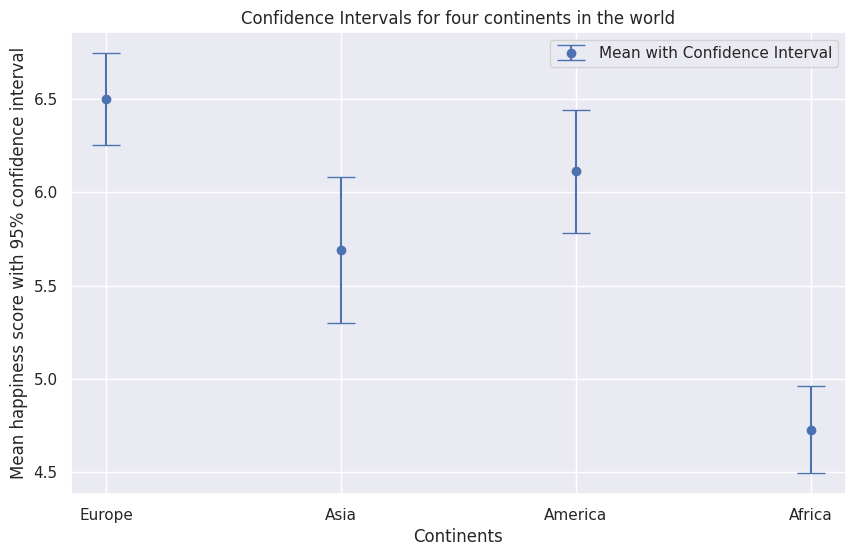

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)

# Plot the lines for each population with confidence intervals
ax.errorbar(x, [np.mean(Europe_ladder), meanAsia_ladder, np.mean(America_ladder), np.mean(Africa_ladder)],yerr=[(confidence_interval_E[1]-confidence_interval_E[0])/2, (confidence_interval_As[1]-confidence_interval_As[0])/2,(confidence_interval_Am[1]-confidence_interval_Am[0])/2, (confidence_interval_A[1]-confidence_interval_A[0])/2],fmt='o'
          , capsize=10, label='Mean with Confidence Interval')

# Customize the axes labels and title
ax.set_xticks(x)
ax.set_xticklabels(['Europe', 'Asia', 'America', 'Africa'])
ax.set_xlabel('Continents')
ax.set_ylabel('Mean happiness score with 95% confidence interval')
ax.set_title('Confidence Intervals for four continents in the world')

# Add a legend
ax.legend()

# Show the plot
plt.show()

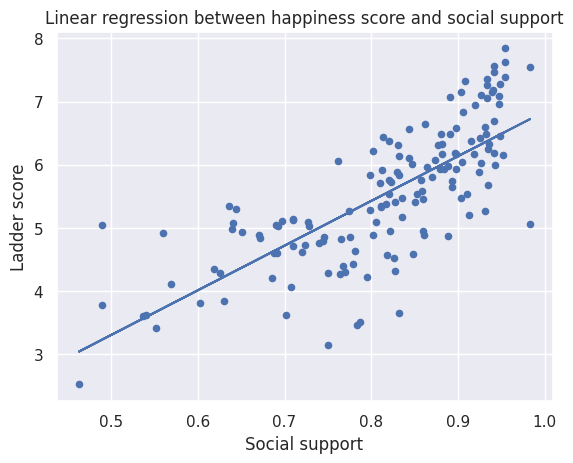

In [ ]:
#ploting economy and happiness score to find for a correlation
data_2021.plot(kind='scatter', x='Social support', y='Ladder score', title='Linear regression between happiness score and social support')
x = data_2021['Social support']
y = data_2021['Ladder score']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x+b)
plt.show()

In [ ]:
import statsmodels.api as sm

In [ ]:
y = data_2021['Ladder score']
x = data_2021['Logged GDP per capita']

model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     243.7
Date:                Tue, 23 May 2023   Prob (F-statistic):           5.23e-33
Time:                        18:10:11   Log-Likelihood:                -148.73
No. Observations:                 149   AIC:                             301.5
Df Residuals:                     147   BIC:                             307.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.37

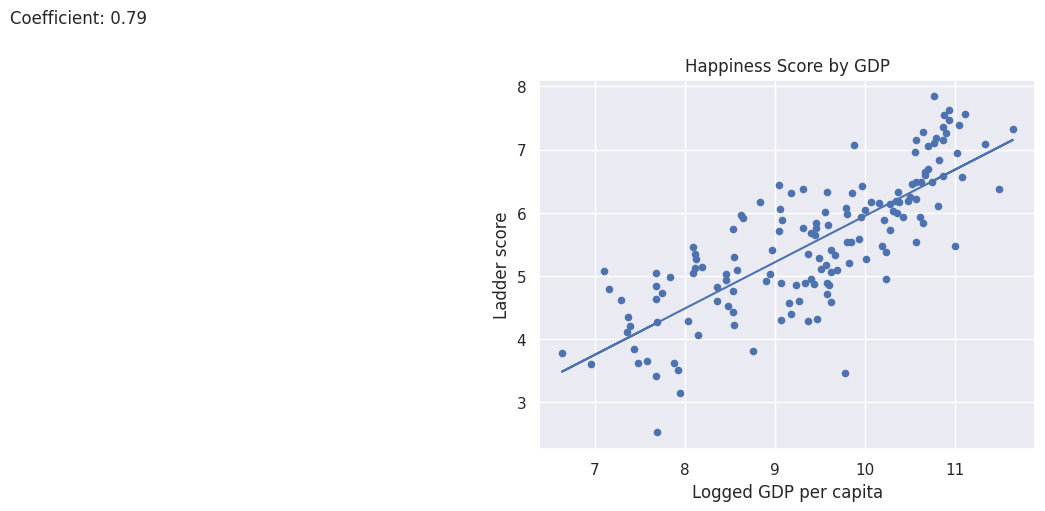

In [ ]:
#ploting economy and happiness score to find for a correlation
data_2021.plot(kind='scatter', x='Logged GDP per capita', y='Ladder score', title='Happiness Score by GDP')
x = data_2021['Logged GDP per capita']
y = data_2021['Ladder score']
corr_coef, p_value = pearsonr(data_2021["Logged GDP per capita"], data_2021["Ladder score"])
plt.text(0.5, 9, f"Coefficient: {corr_coef:.2f}", fontsize=12)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x+b)
plt.show()

**CHECKING NORMALITY**

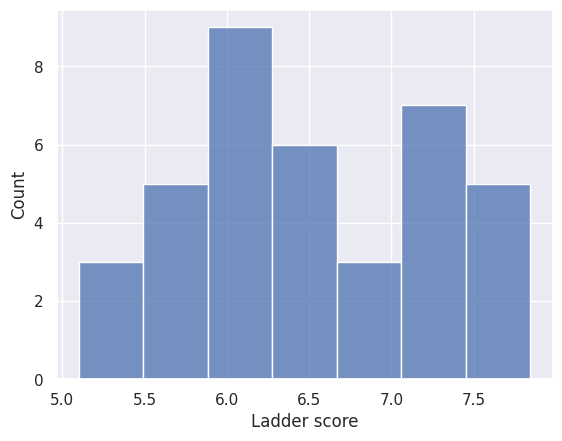

In [ ]:

sns.histplot(data= Europe, x='Ladder score', bins=7)
plt.show()

In [ ]:
mean = np.mean(Europe['Ladder score'])
std = np.std(Europe['Ladder score'])

bins = 7
interval = []
for i in range(1,8):
  val = st.norm.ppf(i/bins, mean, std)
  interval.append(val)
interval

[5.711955532429386,
 6.081666920981744,
 6.3661145456765675,
 6.631464401691855,
 6.915912026386678,
 7.285623414939037,
 inf]

In [ ]:
interval.insert(0, -np.inf)
interval


[-inf,
 5.711955532429386,
 6.081666920981744,
 6.3661145456765675,
 6.631464401691855,
 6.915912026386678,
 7.285623414939037,
 inf]

In [ ]:
df = pd.DataFrame({'lower_limit':interval[:-1], 'upper_limit':interval[1:]})
df

,lower_limit,upper_limit
0,-inf,5.711956
1,5.711956,6.081667
2,6.081667,6.366115
3,6.366115,6.631464
4,6.631464,6.915912
5,6.915912,7.285623
6,7.285623,inf


In [ ]:
life_values = list(sorted(Europe['Ladder score']))
df['obs_freq'] = df.apply(lambda x:sum([i>x['lower_limit'] and i<=x['upper_limit'] for i in life_values]), axis=1)
df['exp_freq'] = 5
df

,lower_limit,upper_limit,obs_freq,exp_freq
0,-inf,5.711956,5,5
1,5.711956,6.081667,7,5
2,6.081667,6.366115,6,5
3,6.366115,6.631464,5,5
4,6.631464,6.915912,2,5
5,6.915912,7.285623,5,5
6,7.285623,inf,8,5


In [ ]:
obs= list(df["obs_freq"])
exp= list(df["exp_freq"])

In [ ]:
chi=0
for i in range(len(obs)):
  chi += ((obs[i]-exp[i])**2)/exp[i]



4.6

In [ ]:
Europe.describe()

,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,3.800000e+01,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,6.498789,0.044158,6.585395,6.412132,10.503447,0.902368,70.932842,0.831132,-0.037079,0.669579,2.430000e+00,1.351368,0.990816,0.707289,0.546842,0.163737,0.172053,2.566684
std,0.746926,0.008452,0.736141,0.757961,0.497492,0.058952,2.740046,0.091489,0.135204,0.246854,9.001008e-16,0.173802,0.132673,0.086335,0.111297,0.088231,0.157502,0.343584
min,5.101000,0.027000,5.202000,5.001000,9.318000,0.697000,63.813000,0.582000,-0.288000,0.179000,2.430000e+00,0.937000,0.529000,0.483000,0.243000,0.000000,0.000000,1.653000
25%,6.002000,0.037000,6.089500,5.914500,10.291750,0.874500,68.724250,0.763750,-0.141250,0.465250,2.430000e+00,1.277500,0.927750,0.637750,0.465000,0.095750,0.041500,2.385000
50%,6.416500,0.043500,6.516500,6.316500,10.563500,0.931000,72.199500,0.843000,-0.034000,0.772500,2.430000e+00,1.372500,1.055000,0.747000,0.561000,0.166000,0.106500,2.581500
75%,7.137500,0.050750,7.215000,7.059250,10.856000,0.942000,72.700000,0.908750,0.041000,0.874000,2.430000e+00,1.474250,1.079000,0.763000,0.640750,0.214250,0.302500,2.797000
max,7.842000,0.059000,7.904000,7.780000,11.647000,0.983000,74.700000,0.960000,0.257000,0.939000,2.430000e+00,1.751000,1.172000,0.826000,0.703000,0.356000,0.485000,3.253000
